## Baseline ABSA

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "../data/processed/mobile_reviews_text_processed.csv"
)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (4200, 34)

Columns:
['review_id', 'customer_name', 'age', 'brand', 'model', 'price_usd', 'price_local', 'currency', 'exchange_rate_to_usd', 'rating', 'review_text', 'sentiment', 'country', 'language', 'review_date', 'verified_purchase', 'battery_life_rating', 'camera_rating', 'performance_rating', 'design_rating', 'display_rating', 'review_length', 'word_count', 'helpful_votes', 'source', 'clean_review', 'clean_word_count', 'clean_char_count', 'mentions_battery', 'mentions_camera', 'mentions_performance', 'mentions_design', 'mentions_display', 'aspect_count']


In [2]:
aspect_columns = [
    "battery",
    "camera",
    "performance",
    "design",
    "display"
]

mention_columns = {
    "battery": "mentions_battery",
    "camera": "mentions_camera",
    "performance": "mentions_performance",
    "design": "mentions_design",
    "display": "mentions_display"
}

rating_columns = {
    "battery": "battery_life_rating",
    "camera": "camera_rating",
    "performance": "performance_rating",
    "design": "design_rating",
    "display": "display_rating"
}

print("Aspects:")
for aspect in aspect_columns:
    print("-", aspect)

Aspects:
- battery
- camera
- performance
- design
- display


In [3]:
print("===== ASPECT MENTION COUNTS =====\n")

for aspect, column in mention_columns.items():
    count = df[column].sum()
    percentage = count / len(df) * 100

    print(
        f"{aspect.capitalize():12s}: "
        f"{count:4d} reviews ({percentage:.2f}%)"
    )

===== ASPECT MENTION COUNTS =====

Battery     : 1887 reviews (44.93%)
Camera      : 2072 reviews (49.33%)
Performance : 2894 reviews (68.90%)
Design      : 1700 reviews (40.48%)
Display     : 2064 reviews (49.14%)


In [4]:
def rating_to_sentiment(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"


for aspect, rating_column in rating_columns.items():

    sentiment_column = f"{aspect}_aspect_sentiment"

    df[sentiment_column] = df[rating_column].apply(
        rating_to_sentiment
    )

print("Aspect sentiment columns created.")

print(
    df[
        [
            "battery_life_rating",
            "battery_aspect_sentiment",
            "camera_rating",
            "camera_aspect_sentiment"
        ]
    ].head(10)
)

Aspect sentiment columns created.
   battery_life_rating battery_aspect_sentiment  camera_rating  \
0                    5                 Positive              5   
1                    4                 Positive              4   
2                    4                 Positive              5   
3                    3                  Neutral              2   
4                    5                 Positive              4   
5                    4                 Positive              4   
6                    3                  Neutral              3   
7                    4                 Positive              3   
8                    4                 Positive              4   
9                    4                 Positive              4   

  camera_aspect_sentiment  
0                Positive  
1                Positive  
2                Positive  
3                Negative  
4                Positive  
5                Positive  
6                 Neutral  
7              

In [5]:
absa_records = []

for index, row in df.iterrows():

    for aspect in aspect_columns:

        mention_column = mention_columns[aspect]
        rating_column = rating_columns[aspect]
        sentiment_column = f"{aspect}_aspect_sentiment"

        # Only include the aspect if it was detected in the review
        if row[mention_column] == 1:

            absa_records.append({
                "review_id": index,
                "brand": row["brand"],
                "model": row["model"],
                "review_text": row["review_text"],
                "clean_review": row["clean_review"],
                "aspect": aspect,
                "aspect_rating": row[rating_column],
                "aspect_sentiment": row[sentiment_column]
            })


absa_df = pd.DataFrame(absa_records)

print("===== ABSA DATASET =====")
print("Shape:", absa_df.shape)

print("\nFirst 10 records:")
display(absa_df.head(10))

===== ABSA DATASET =====
Shape: (10617, 8)

First 10 records:


,review_id,brand,model,review_text,clean_review,aspect,aspect_rating,aspect_sentiment
0,0,Samsung,Galaxy S25 Ultra,usually leaves plenty of charge by bedtime. ap...,usually leaves plenty of charge by bedtime. ap...,battery,5,Positive
1,0,Samsung,Galaxy S25 Ultra,usually leaves plenty of charge by bedtime. ap...,usually leaves plenty of charge by bedtime. ap...,performance,5,Positive
2,0,Samsung,Galaxy S25 Ultra,usually leaves plenty of charge by bedtime. ap...,usually leaves plenty of charge by bedtime. ap...,display,5,Positive
3,1,Google,Pixel 10,"is adequate for most daily tasks. Still, I rar...","is adequate for most daily tasks. still, i rar...",battery,4,Positive
4,2,Realme,Realme GT 7 Pro,"At the same time, the buttons do not feel as r...","at the same time, the buttons do not feel as r...",battery,4,Positive
5,2,Realme,Realme GT 7 Pro,"At the same time, the buttons do not feel as r...","at the same time, the buttons do not feel as r...",camera,5,Positive
6,2,Realme,Realme GT 7 Pro,"At the same time, the buttons do not feel as r...","at the same time, the buttons do not feel as r...",performance,4,Positive
7,2,Realme,Realme GT 7 Pro,"At the same time, the buttons do not feel as r...","at the same time, the buttons do not feel as r...",design,3,Neutral
8,3,Apple,iPhone 16e,longer gaming sessions can introduce stutter. ...,longer gaming sessions can introduce stutter. ...,camera,2,Negative
9,3,Apple,iPhone 16e,longer gaming sessions can introduce stutter. ...,longer gaming sessions can introduce stutter. ...,performance,2,Negative


In [6]:
print("===== ASPECT DISTRIBUTION =====\n")

print(
    absa_df["aspect"]
    .value_counts()
)

print("\n===== ASPECT SENTIMENT DISTRIBUTION =====\n")

aspect_sentiment_table = pd.crosstab(
    absa_df["aspect"],
    absa_df["aspect_sentiment"]
)

print(aspect_sentiment_table)

===== ASPECT DISTRIBUTION =====

aspect
performance    2894
camera         2072
display        2064
battery        1887
design         1700
Name: count, dtype: int64

===== ASPECT SENTIMENT DISTRIBUTION =====

aspect_sentiment  Negative  Neutral  Positive
aspect                                       
battery                144      394      1349
camera                 277      476      1319
design                 115      475      1110
display                121      374      1569
performance            245      652      1997


In [7]:
aspect_sentiment_percentage = pd.crosstab(
    absa_df["aspect"],
    absa_df["aspect_sentiment"],
    normalize="index"
) * 100

print("===== ASPECT SENTIMENT (%) =====")

print(
    aspect_sentiment_percentage.round(2)
)

===== ASPECT SENTIMENT (%) =====
aspect_sentiment  Negative  Neutral  Positive
aspect                                       
battery               7.63    20.88     71.49
camera               13.37    22.97     63.66
design                6.76    27.94     65.29
display               5.86    18.12     76.02
performance           8.47    22.53     69.00


In [8]:
absa_output_path = "../data/processed/absa_dataset.csv"

absa_df.to_csv(
    absa_output_path,
    index=False
)

print("ABSA dataset saved successfully.")
print("Saved to:", absa_output_path)

ABSA dataset saved successfully.
Saved to: ../data/processed/absa_dataset.csv


In [9]:
# Create aspect-conditioned input text

absa_df["model_input"] = (
    "aspect: "
    + absa_df["aspect"].str.lower()
    + " review: "
    + absa_df["clean_review"]
)

print(absa_df[[
    "aspect",
    "clean_review",
    "aspect_sentiment",
    "model_input"
]].head(10))

        aspect                                       clean_review  \
0      battery  usually leaves plenty of charge by bedtime. ap...   
1  performance  usually leaves plenty of charge by bedtime. ap...   
2      display  usually leaves plenty of charge by bedtime. ap...   
3      battery  is adequate for most daily tasks. still, i rar...   
4      battery  at the same time, the buttons do not feel as r...   
5       camera  at the same time, the buttons do not feel as r...   
6  performance  at the same time, the buttons do not feel as r...   
7       design  at the same time, the buttons do not feel as r...   
8       camera  longer gaming sessions can introduce stutter. ...   
9  performance  longer gaming sessions can introduce stutter. ...   

  aspect_sentiment                                        model_input  
0         Positive  aspect: battery review: usually leaves plenty ...  
1         Positive  aspect: performance review: usually leaves ple...  
2         Positive  aspe

In [10]:
label2id_absa = {
    "Negative": 0,
    "Neutral": 1,
    "Positive": 2
}

id2label_absa = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

absa_df["label"] = absa_df["aspect_sentiment"].map(
    label2id_absa
)

print(
    absa_df["label"]
    .value_counts()
    .sort_index()
)

label
0     902
1    2371
2    7344
Name: count, dtype: int64


In [11]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(
        absa_df,
        y=absa_df["label"],
        groups=absa_df["review_id"]
    )
)

absa_train = absa_df.iloc[train_idx].copy()
absa_test = absa_df.iloc[test_idx].copy()

print("Training aspect pairs:", len(absa_train))
print("Testing aspect pairs:", len(absa_test))

print("\nUnique training reviews:", absa_train["review_id"].nunique())
print("Unique testing reviews:", absa_test["review_id"].nunique())

overlap = set(absa_train["review_id"]) & set(
    absa_test["review_id"]
)

print("\nReview ID overlap:", len(overlap))

Training aspect pairs: 8519
Testing aspect pairs: 2098

Unique training reviews: 3296
Unique testing reviews: 825

Review ID overlap: 0


In [12]:
print("===== TRAINING LABEL DISTRIBUTION =====")

print(
    absa_train["aspect_sentiment"]
    .value_counts()
)

print("\n===== TEST LABEL DISTRIBUTION =====")

print(
    absa_test["aspect_sentiment"]
    .value_counts()
)

===== TRAINING LABEL DISTRIBUTION =====
aspect_sentiment
Positive    5972
Neutral     1850
Negative     697
Name: count, dtype: int64

===== TEST LABEL DISTRIBUTION =====
aspect_sentiment
Positive    1372
Neutral      521
Negative     205
Name: count, dtype: int64


In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

absa_baseline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            ngram_range=(1, 2),
            stop_words="english",
            min_df=2,
            max_df=0.95,
            sublinear_tf=True
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    )
])

print("ABSA TF-IDF pipeline created successfully.")

ABSA TF-IDF pipeline created successfully.


In [14]:
print("Training ABSA TF-IDF model...")

absa_baseline.fit(
    absa_train["model_input"],
    absa_train["label"]
)

print("ABSA baseline training completed.")

Training ABSA TF-IDF model...
ABSA baseline training completed.


In [15]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report
)

absa_predictions = absa_baseline.predict(
    absa_test["model_input"]
)

absa_true = absa_test["label"]

accuracy = accuracy_score(
    absa_true,
    absa_predictions
)

precision, recall, macro_f1, _ = (
    precision_recall_fscore_support(
        absa_true,
        absa_predictions,
        average="macro",
        zero_division=0
    )
)

print("===== ABSA BASELINE PERFORMANCE =====")
print(f"Accuracy      : {accuracy:.4f}")
print(f"Macro Precision: {precision:.4f}")
print(f"Macro Recall   : {recall:.4f}")
print(f"Macro F1       : {macro_f1:.4f}")

===== ABSA BASELINE PERFORMANCE =====
Accuracy      : 0.6335
Macro Precision: 0.5519
Macro Recall   : 0.6261
Macro F1       : 0.5670


In [16]:
print("===== ABSA CLASSIFICATION REPORT =====")

print(
    classification_report(
        absa_true,
        absa_predictions,
        labels=[0, 1, 2],
        target_names=[
            "Negative",
            "Neutral",
            "Positive"
        ],
        digits=4,
        zero_division=0
    )
)

===== ABSA CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

    Negative     0.3457    0.6341    0.4475       205
     Neutral     0.4560    0.5969    0.5170       521
    Positive     0.8538    0.6472    0.7363      1372

    accuracy                         0.6335      2098
   macro avg     0.5519    0.6261    0.5670      2098
weighted avg     0.7054    0.6335    0.6536      2098



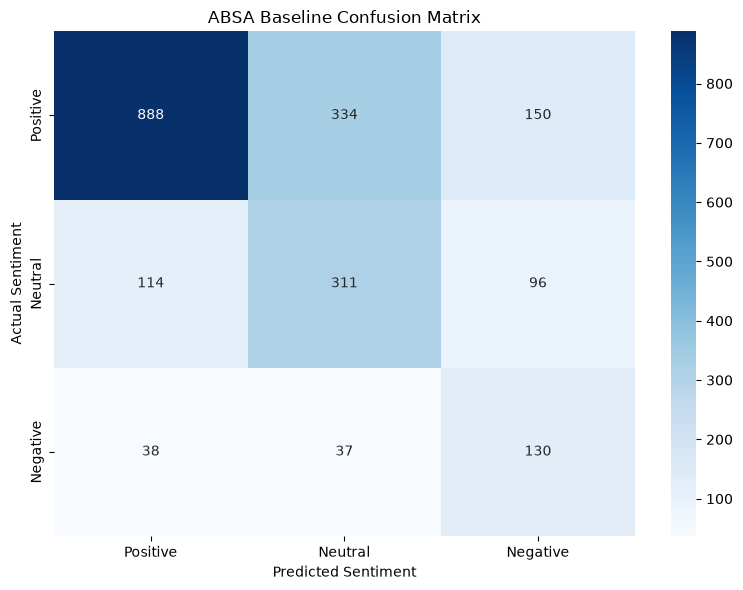

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    absa_true,
    absa_predictions,
    labels=[2, 1, 0]
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Positive",
        "Neutral",
        "Negative"
    ],
    yticklabels=[
        "Positive",
        "Neutral",
        "Negative"
    ]
)

plt.title("ABSA Baseline Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.tight_layout()
plt.show()

In [18]:
import joblib

absa_model_path = "../models/trained_models/absa_tfidf_baseline.pkl"

joblib.dump(
    absa_baseline,
    absa_model_path
)

print("ABSA baseline saved successfully.")
print("Saved to:", absa_model_path)

ABSA baseline saved successfully.
Saved to: ../models/trained_models/absa_tfidf_baseline.pkl


## Transformer-Based ABSA

In [19]:
import torch
import numpy as np

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

print("Transformer libraries loaded.")
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Transformer libraries loaded.
PyTorch: 2.14.0+cpu
CUDA available: False


In [20]:
train_dataset = Dataset.from_pandas(
    absa_train[["model_input", "label"]],
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    absa_test[["model_input", "label"]],
    preserve_index=False
)

print("Training aspect pairs:", len(train_dataset))
print("Testing aspect pairs:", len(test_dataset))

Training aspect pairs: 8519
Testing aspect pairs: 2098


In [21]:
MODEL_NAME = "distilbert-base-uncased"

tokenizer_absa = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

model_absa = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label_absa,
    label2id=label2id_absa
)

print("DistilBERT ABSA model loaded successfully.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT ABSA model loaded successfully.


In [22]:
train_dataset = Dataset.from_pandas(
    absa_train[["model_input", "label"]],
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    absa_test[["model_input", "label"]],
    preserve_index=False
)

print("Training aspect pairs:", len(train_dataset))
print("Testing aspect pairs:", len(test_dataset))

Training aspect pairs: 8519
Testing aspect pairs: 2098


In [23]:
def tokenize_absa(batch):
    return tokenizer_absa(
        batch["model_input"],
        truncation=True,
        max_length=128
    )


train_tokenized_absa = train_dataset.map(
    tokenize_absa,
    batched=True
)

test_tokenized_absa = test_dataset.map(
    tokenize_absa,
    batched=True
)

print("ABSA tokenization completed.")

Map:   0%|          | 0/8519 [00:00<?, ? examples/s]

Map:   0%|          | 0/2098 [00:00<?, ? examples/s]

ABSA tokenization completed.


In [24]:
train_tokenized_absa = train_tokenized_absa.remove_columns(
    ["model_input"]
)

test_tokenized_absa = test_tokenized_absa.remove_columns(
    ["model_input"]
)

print(train_tokenized_absa)

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 8519
})


In [25]:
data_collator_absa = DataCollatorWithPadding(
    tokenizer=tokenizer_absa
)

print("ABSA dynamic padding collator created.")

ABSA dynamic padding collator created.


In [26]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1, 2])

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=absa_train["label"].values
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float
)

print("ABSA class weights:")
print(class_weights)

print("\nLabel mapping:")
print(id2label_absa)

ABSA class weights:
tensor([4.0741, 1.5350, 0.4755])

Label mapping:
{0: 'Negative', 1: 'Neutral', 2: 'Positive'}


In [27]:
import torch.nn as nn


class WeightedTrainer(Trainer):

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None
    ):

        labels = inputs.pop("labels")

        outputs = model(**inputs)

        logits = outputs.logits

        loss_function = nn.CrossEntropyLoss(
            weight=class_weights.to(logits.device)
        )

        loss = loss_function(
            logits,
            labels
        )

        return (
            (loss, outputs)
            if return_outputs
            else loss
        )


print("WeightedTrainer created successfully.")

WeightedTrainer created successfully.


In [28]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)


def compute_absa_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=-1
    )

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            labels,
            predictions,
            average="macro",
            zero_division=0
        )
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    return {
        "accuracy": accuracy,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1
    }


print("ABSA metrics created.")

ABSA metrics created.


In [29]:
absa_training_args = TrainingArguments(
    output_dir="../models/trained_models/distilbert_absa",

    num_train_epochs=2,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    learning_rate=2e-5,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,

    metric_for_best_model="macro_f1",
    greater_is_better=True,

    logging_steps=25,

    report_to="none",

    fp16=False,

    dataloader_pin_memory=False
)

print("ABSA training configuration created.")

ABSA training configuration created.


In [30]:
absa_trainer = WeightedTrainer(
    model=model_absa,
    args=absa_training_args,

    train_dataset=train_tokenized_absa,
    eval_dataset=test_tokenized_absa,

    data_collator=data_collator_absa,

    compute_metrics=compute_absa_metrics
)

print("ABSA Transformer Trainer created successfully.")

ABSA Transformer Trainer created successfully.


In [31]:
print("Starting Transformer ABSA training...")
print("Training aspect pairs:", len(train_tokenized_absa))
print("Testing aspect pairs:", len(test_tokenized_absa))
print("Epochs:", absa_training_args.num_train_epochs)
print()

absa_train_result = absa_trainer.train()

print("\n===== ABSA TRANSFORMER TRAINING COMPLETED =====")
print(absa_train_result)

Starting Transformer ABSA training...
Training aspect pairs: 8519
Testing aspect pairs: 2098
Epochs: 2



Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,0.514037,0.633866,0.793136,0.778286,0.752720,0.755080
2,0.386576,0.556722,0.808866,0.810272,0.775397,0.779166


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


===== ABSA TRANSFORMER TRAINING COMPLETED =====
TrainOutput(global_step=2130, training_loss=0.7234212452257184, metrics={'train_runtime': 1875.1066, 'train_samples_per_second': 9.086, 'train_steps_per_second': 1.136, 'total_flos': 315406361318112.0, 'train_loss': 0.7234212452257184, 'epoch': 2.0})


In [32]:
# Final evaluation on the held-out ABSA test set

absa_pred_output = absa_trainer.predict(
    test_tokenized_absa
)

absa_pred_logits = absa_pred_output.predictions

absa_true_labels = absa_test["label"].values

absa_pred_labels = np.argmax(
    absa_pred_logits,
    axis=-1
)

print("ABSA predictions generated.")
print("Test aspect pairs:", len(absa_pred_labels))

ABSA predictions generated.
Test aspect pairs: 2098


In [33]:
print("===== DISTILBERT ABSA CLASSIFICATION REPORT =====")

print(
    classification_report(
        absa_true_labels,
        absa_pred_labels,
        labels=[0, 1, 2],
        target_names=[
            "Negative",
            "Neutral",
            "Positive"
        ],
        digits=4,
        zero_division=0
    )
)

===== DISTILBERT ABSA CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

    Negative     0.9067    0.6634    0.7662       205
     Neutral     0.6091    0.8464    0.7084       521
    Positive     0.9150    0.8163    0.8629      1372

    accuracy                         0.8089      2098
   macro avg     0.8103    0.7754    0.7792      2098
weighted avg     0.8382    0.8089    0.8151      2098



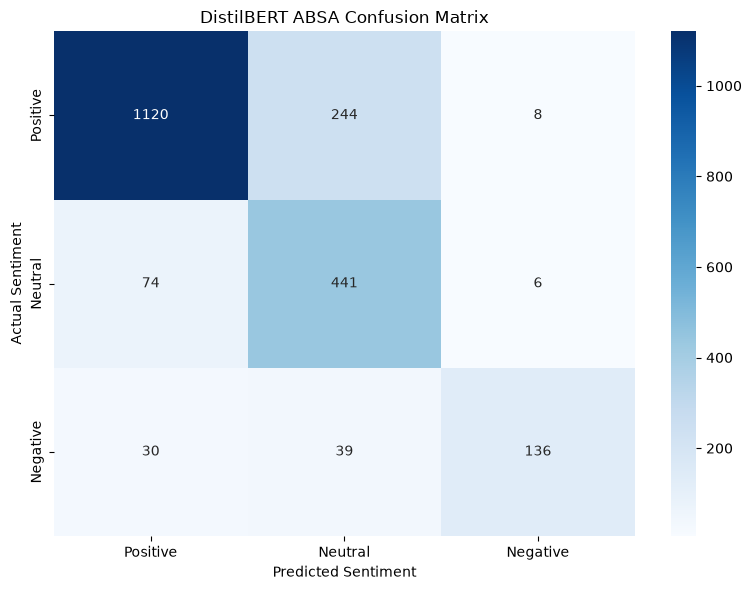

In [34]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_absa = confusion_matrix(
    absa_true_labels,
    absa_pred_labels,
    labels=[2, 1, 0]
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_absa,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Positive",
        "Neutral",
        "Negative"
    ],
    yticklabels=[
        "Positive",
        "Neutral",
        "Negative"
    ]
)

plt.title("DistilBERT ABSA Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.tight_layout()
plt.show()

In [35]:
ABSA_MODEL_PATH = "../models/trained_models/distilbert_absa"

absa_trainer.save_model(
    ABSA_MODEL_PATH
)

tokenizer_absa.save_pretrained(
    ABSA_MODEL_PATH
)

print("DistilBERT ABSA model saved successfully.")
print("Saved to:", ABSA_MODEL_PATH)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

DistilBERT ABSA model saved successfully.
Saved to: ../models/trained_models/distilbert_absa


In [36]:
# Create final ABSA prediction dataset

absa_results = absa_test[
    [
        "review_id",
        "brand",
        "model",
        "review_text",
        "aspect",
        "aspect_rating",
        "aspect_sentiment"
    ]
].copy()

absa_results["predicted_sentiment"] = [
    id2label_absa[int(label)]
    for label in absa_pred_labels
]

# Get prediction probabilities
absa_probabilities = torch.softmax(
    torch.tensor(absa_pred_logits),
    dim=1
).numpy()

absa_results["prediction_confidence"] = (
    absa_probabilities.max(axis=1)
)

print("ABSA prediction dataset created.")
print(absa_results.head(10))

ABSA prediction dataset created.
    review_id    brand          model  \
18          7  Samsung  Galaxy A56 5G   
19          7  Samsung  Galaxy A56 5G   
22          9  OnePlus     OnePlus 13   
23          9  OnePlus     OnePlus 13   
24          9  OnePlus     OnePlus 13   
25          9  OnePlus     OnePlus 13   
32         13    Apple      iPhone 16   
33         13    Apple      iPhone 16   
38         15    Apple      iPhone 16   
39         15    Apple      iPhone 16   

                                          review_text       aspect  \
18  I mostly use it for work and messaging. works ...       camera   
19  I mostly use it for work and messaging. works ...      display   
22  the finish looks more premium in person. On th...      battery   
23  the finish looks more premium in person. On th...  performance   
24  the finish looks more premium in person. On th...       design   
25  the finish looks more premium in person. On th...      display   
32  That said, scrolling 

In [37]:
print("===== ACTUAL VS PREDICTED =====")

comparison_table = pd.crosstab(
    absa_results["aspect_sentiment"],
    absa_results["predicted_sentiment"]
)

print(comparison_table)

===== ACTUAL VS PREDICTED =====
predicted_sentiment  Negative  Neutral  Positive
aspect_sentiment                                
Negative                  136       39        30
Neutral                     6      441        74
Positive                    8      244      1120


In [38]:
print("===== PREDICTION CONFIDENCE =====")

print(
    absa_results["prediction_confidence"].describe()
)

===== PREDICTION CONFIDENCE =====
count    2098.000000
mean        0.876535
std         0.150901
min         0.416670
25%         0.839292
50%         0.919798
75%         0.989411
max         0.994652
Name: prediction_confidence, dtype: float64


In [39]:
ABSA_RESULTS_PATH = "../data/processed/absa_predictions.csv"

absa_results.to_csv(
    ABSA_RESULTS_PATH,
    index=False
)

print("ABSA predictions saved successfully.")
print("Saved to:", ABSA_RESULTS_PATH)

ABSA predictions saved successfully.
Saved to: ../data/processed/absa_predictions.csv
